In [3]:
import pandas as pd
from scipy.stats import levene
from model_comparison import (calc_classification_metrics, 
                              make_ci_plot_grid, 
                              make_mcs_plot_grid, 
                              make_normality_diagnostic,
                              make_boxplots_parametric, 
                              make_scatterplot,
                              rm_tukey_hsd, 
                              make_curve_plots)
import pickle
from pyparsing import col

In [4]:
tm60_cv = pd.read_csv(r'M:\ML_scripts\polaris\tm60-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])
cm60_cv = pd.read_csv(r'M:\ML_scripts\polaris\cm60-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])

tm65_cv = pd.read_csv(r'M:\ML_scripts\polaris\tm65-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])
cm65_cv = pd.read_csv(r'M:\ML_scripts\polaris\cm65-trials-data\best_trial_fold_metrics.csv').drop(columns=['Unnamed: 0'])

metric_df = pd.concat([tm60_cv, cm60_cv, tm65_cv, cm65_cv], axis=0)

metric_df['cv_cycle'] = metric_df.index
metric_df['split'] = 'stratified'

metric_df = metric_df.rename(columns={'model': 'method'})

metric_list = list(metric_df.columns[1:4])

x60 = metric_df[metric_df['method'].str.contains('60')]
x65 = metric_df[metric_df['method'].str.contains('65')]

TM = metric_df[metric_df['method'].str.contains('tm')]
CM = metric_df[metric_df['method'].str.contains('cm')]


# NS = pd.read_csv(r'M:\ML_scripts\polaris\ns-combined-best-fold-metrics.csv').drop(columns=['Unnamed: 0'])

# ns_metric_df = NS

# ns_metric_df['cv_cycle'] = ns_metric_df.index
# ns_metric_df['split'] = 'stratified'
# ns_metric_df = ns_metric_df.rename(columns={'model': 'method'})

In [5]:
x60

,method,roc_auc,mcc,auc_pr_cal,cv_cycle,split
0,tm60_RF,0.768505,0.377974,0.246592,0,stratified
1,tm60_RF,0.726415,0.352322,0.323907,1,stratified
2,tm60_RF,0.752903,0.357424,0.273157,2,stratified
3,tm60_RF,0.751814,0.398801,0.215430,3,stratified
4,tm60_RF,0.774311,0.390421,0.451072,4,stratified
5,tm60_RF,0.667997,0.241948,0.207706,5,stratified
6,tm60_RF,0.801887,0.430183,0.413831,6,stratified
7,tm60_RF,0.845065,0.466618,0.578180,7,stratified
8,tm60_RF,0.713716,0.220982,0.361918,8,stratified
9,tm60_RF,0.742380,0.352322,0.260096,9,stratified


## homogeneity of variances assumption

In [6]:
for metric in metric_list:
    groups = x60.groupby('method')[metric].apply(list)
    stat, pvalue = levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

variances_by_model = x60.groupby('method')[metric_list].var()
max_fold_diff = variances_by_model.max() / variances_by_model.min()
print('\n',max_fold_diff)

Levene test for roc_auc: p-value = 0.7343679331262741
Levene test for mcc: p-value = 0.5619852834606832
Levene test for auc_pr_cal: p-value = 0.499298181775204

 roc_auc       1.617491
mcc           2.011570
auc_pr_cal    1.813995
dtype: float64


## the normality assumption

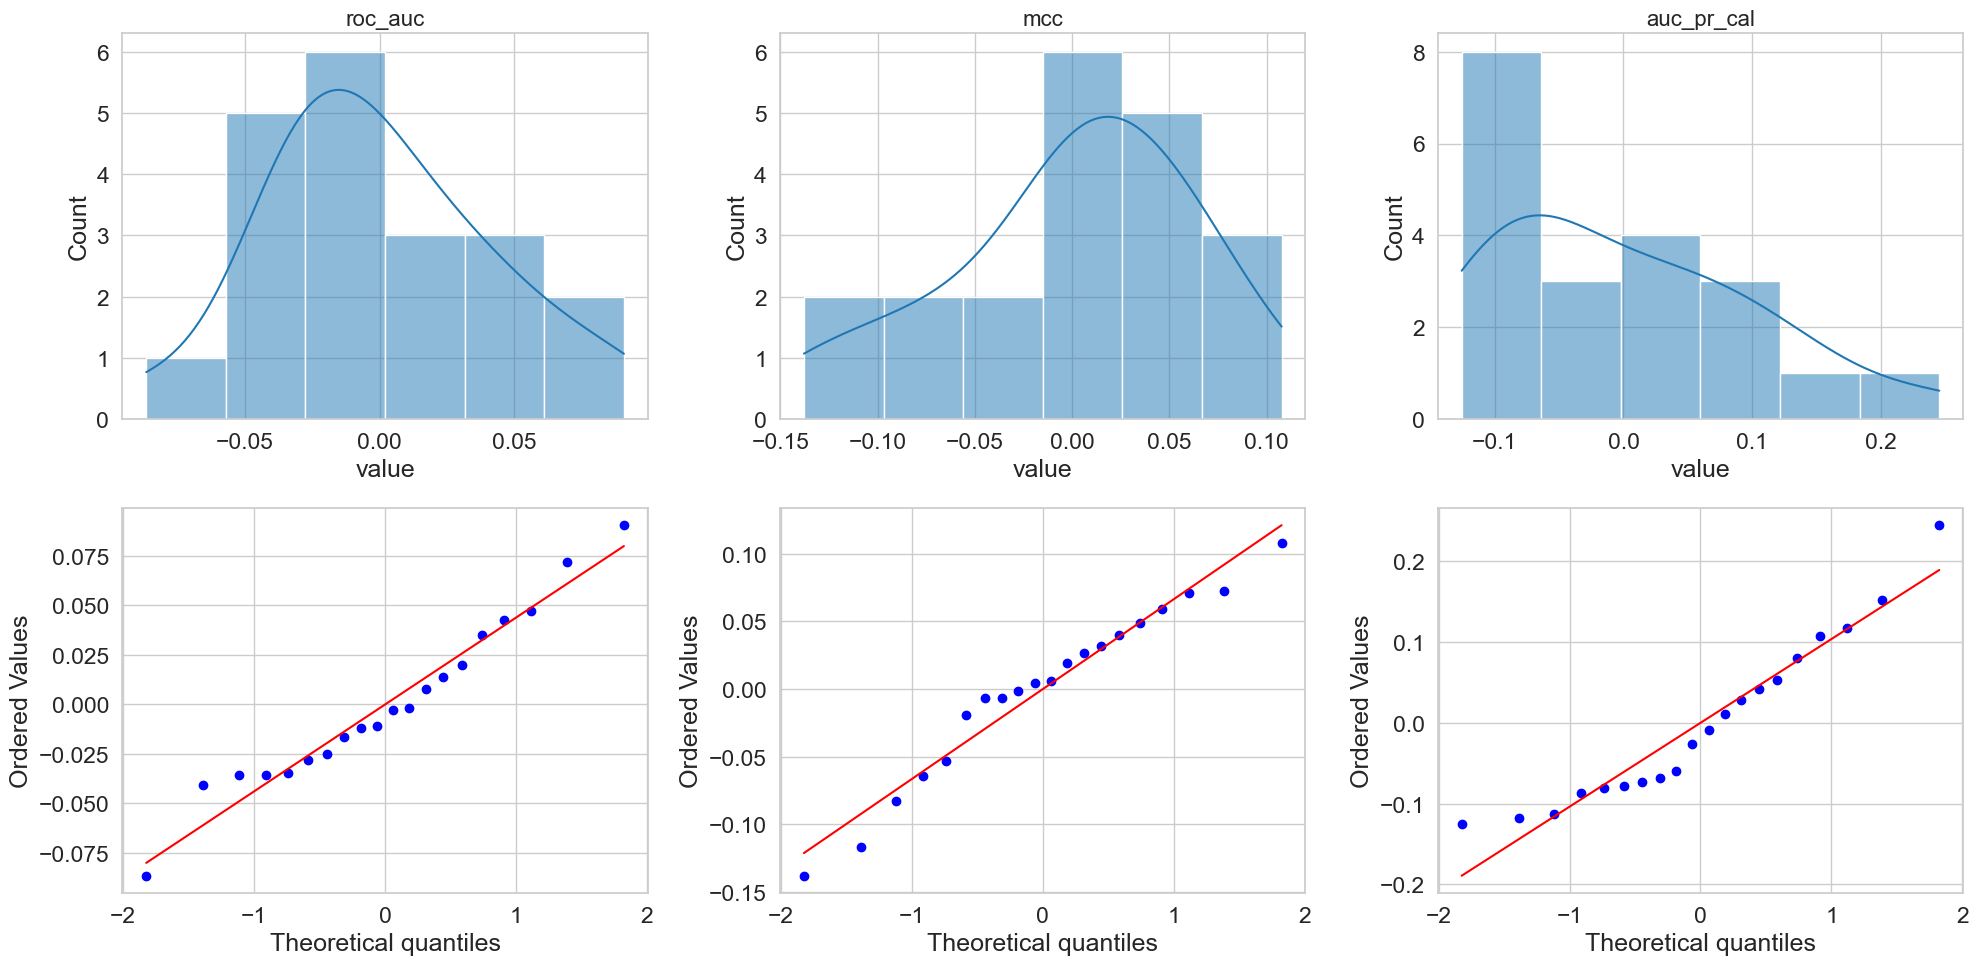

In [7]:
make_normality_diagnostic(x60.copy(), metric_list)

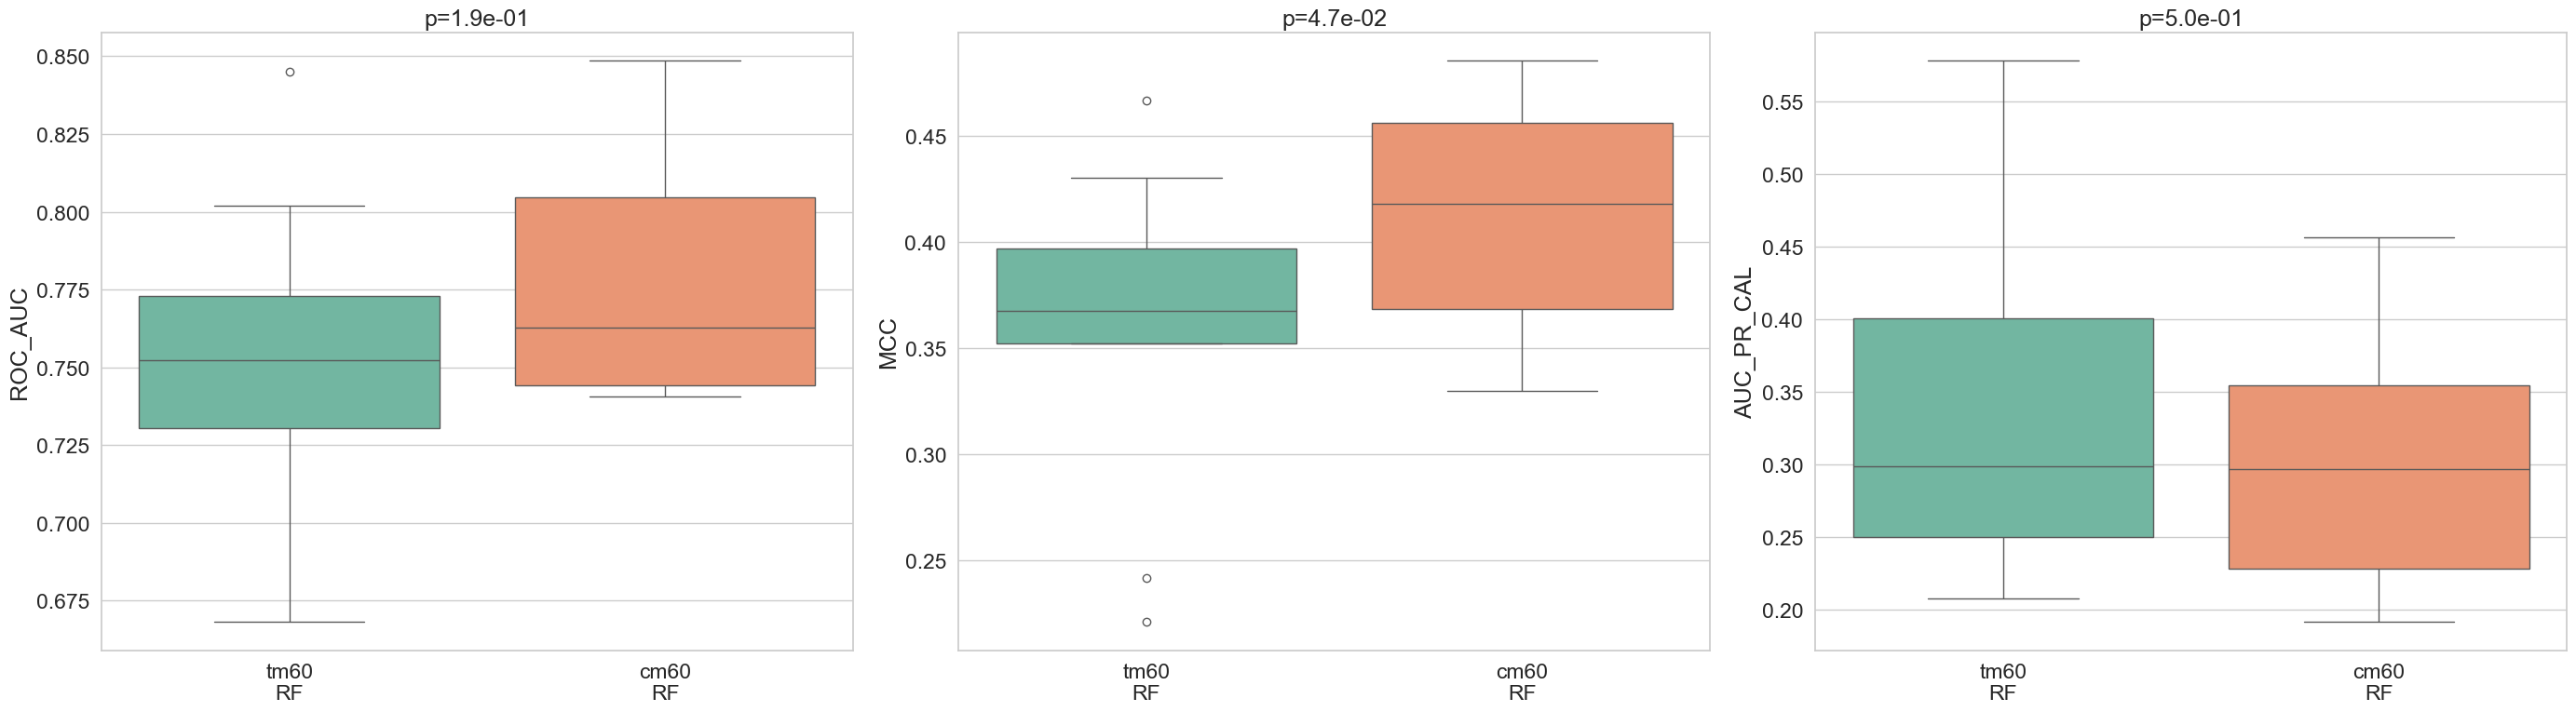

In [8]:
make_boxplots_parametric(x60, metric_list)

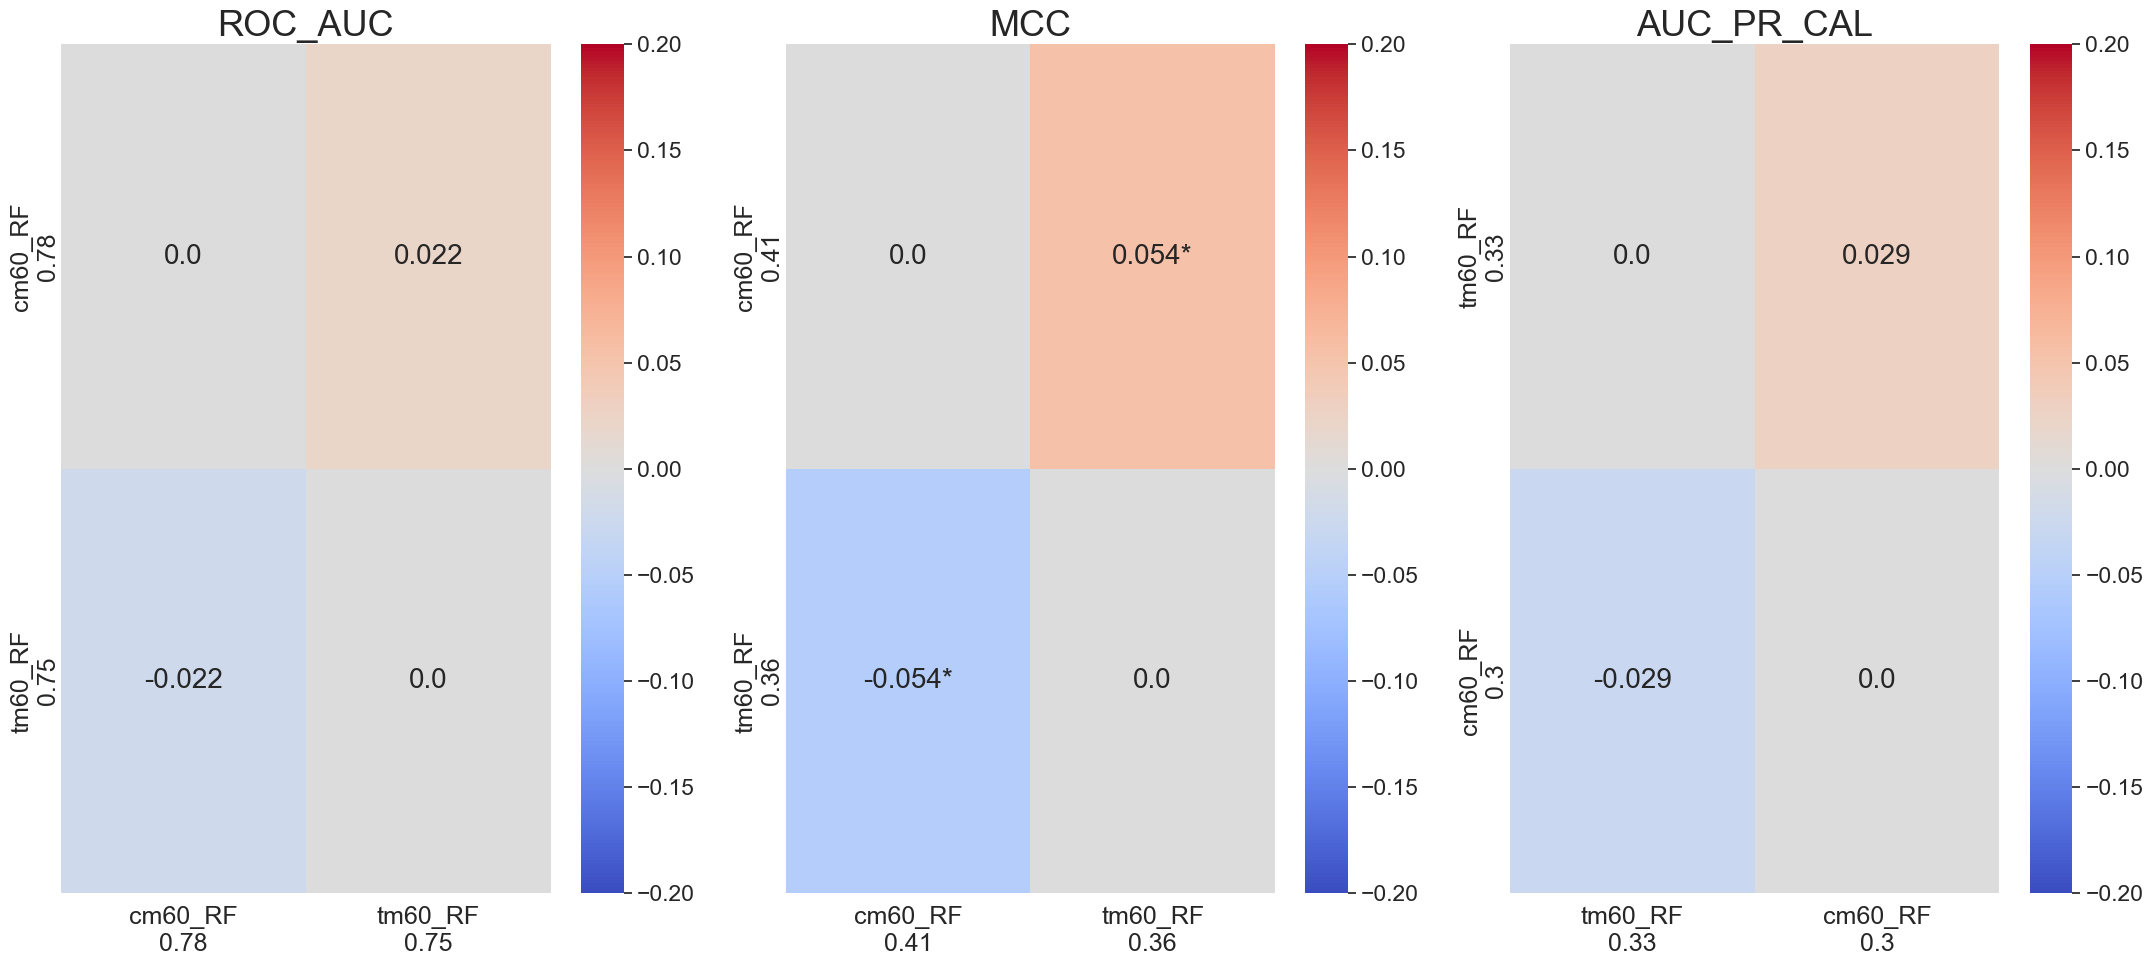

In [9]:
import importlib
import model_comparison

importlib.reload(model_comparison)

effect_dict = {'roc_auc':.1, 'mcc':.1, 'auc_pr_cal':.1}
direction_dict = {'roc_auc':'maximize', 'mcc':'maximize', 'auc_pr_cal':'maximize'}    

model_comparison.make_mcs_plot_grid(x60, metric_list, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(22, 10), cell_text_size=20, axis_text_size=18, title_text_size=26, show_diff=True, sort_axes=True)

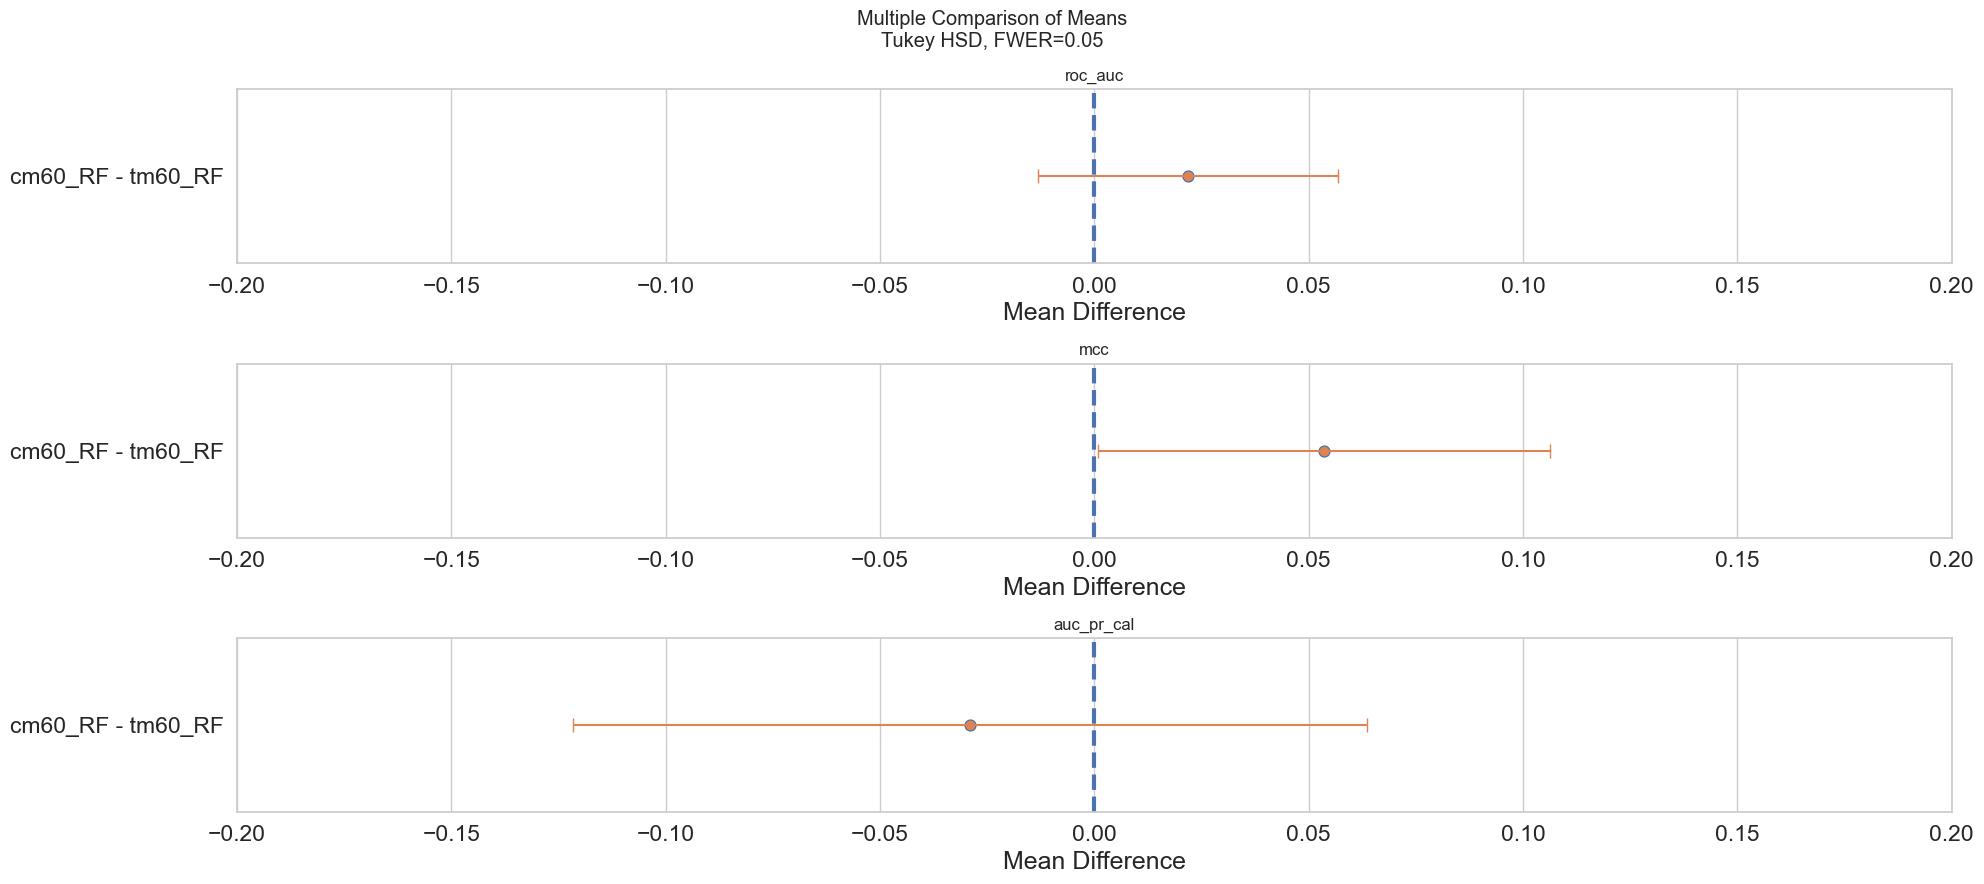

In [10]:
model_comparison.make_ci_plot_grid(x60, metric_list, "method")